Saved figure -> /home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_base/mpc_overview.png


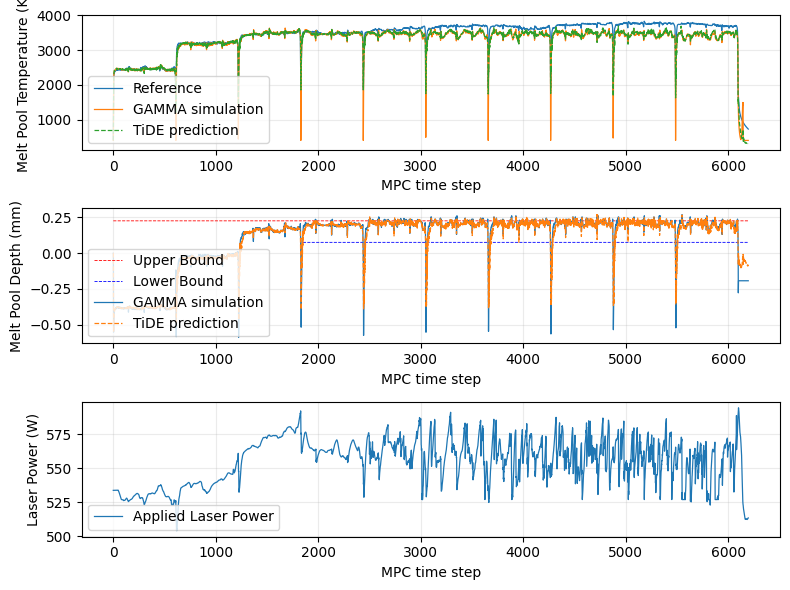

In [19]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
입력 CSV 컬럼(헤더 필요):
gamma_result_temp,gamma_result_depth,ref,TiDE_pred_temp,TiDE_pred_depth,Time,LP
"""

def plot_from_csv(
    csv_path,
    out_path="mpc_overview.png",
    depth_upper=0.225,
    depth_lower=None,   # 예: 0.075 (없으면 None)
    figsize=(8, 9)
):
    df = pd.read_csv(csv_path)

    # ── 시계열 ─────────────────────────────────────────────
    t = np.arange(len(df))
    ref        = df["ref"].to_numpy()
    sim_temp   = df["gamma_result_temp"].to_numpy()
    sim_depth  = df["gamma_result_depth"].to_numpy()
    tide_temp  = df["TiDE_pred_temp"].to_numpy()
    tide_depth = df["TiDE_pred_depth"].to_numpy()
    power      = df["LP"].to_numpy()

    # ── Figure ─────────────────────────────────────────────
    plt.figure(figsize=figsize)

    lw_main = 0.9   # 일반 라인
    lw_pred = 0.9   # 예측 라인
    lw_bound = 0.6  # bound 선

    # ── 1. Melt Pool Temperature ──────────────────────────
    plt.subplot(3, 1, 1)
    plt.plot(t, ref,        label="Reference",        linewidth=lw_main)
    plt.plot(t, sim_temp,   label="GAMMA simulation", linewidth=lw_main)
    plt.plot(t, tide_temp,  label="TiDE prediction",
             linewidth=lw_pred, linestyle="--", color="tab:green")

    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Temperature (K)")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.25)

    # ── 2. Melt Pool Depth ────────────────────────────────
    plt.subplot(3, 1, 2)
    plt.plot(t, np.full(len(t), depth_upper, dtype=float), 'r--',
            linewidth=lw_bound, label="Upper Bound")

    if depth_lower is not None:
        # t < 1850 → NaN 으로 처리해서 라인이 안그려짐
        lower_line = np.where(t >= 1850, depth_lower, np.nan)
        plt.plot(t, lower_line, 'b--', linewidth=lw_bound, label="Lower Bound")

    plt.plot(t, sim_depth,  label="GAMMA simulation", linewidth=lw_main)
    plt.plot(t, tide_depth, label="TiDE prediction",
            linewidth=lw_pred, linestyle="--", color="tab:orange")

    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.25)


    # ── 3. Laser Power ────────────────────────────────────
    plt.subplot(3, 1, 3)
    plt.plot(t, power, label="Applied Laser Power", linewidth=lw_main)

    # (선택) Policy Output을 별도 배열로 추가 가능:
    # plt.plot(t, policy_output, label="Policy Output",
    #          linestyle="--", color="tab:red", linewidth=lw_pred)

    plt.ylabel("Laser Power (W)")
    plt.xlabel("MPC time step")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    print(f"Saved figure -> {os.path.abspath(out_path)}")


# ── 실행 예시 ─────────────────────────────────────────────
if __name__ == "__main__":
    csv_file = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_base/profile_1_MPC_w_depth_control_0925.csv"

    plot_from_csv(
        csv_path=csv_file,
        out_path="mpc_overview.png",
        depth_upper=0.225,
        depth_lower=0.075,  # 필요 없으면 None
        figsize=(8, 6)
    )
